<div style="background:linear-gradient(90deg,#1f3a5f,#3c7a89);color:#fff;padding:18px 24px;border-radius:10px;font-family:Georgia,serif"><h1 style="margin:0;font-size:24px">Seasonal Flu Vaccine Prediction</h1><p style="margin:6px 0 0;color:#f0d9a8;font-size:15px">Group A &nbsp;&bull;&nbsp; Weighted Ensemble &nbsp;&bull;&nbsp; Author: Member 5</p></div>

## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**1. Imports**</span>

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report, roc_curve)
SEED=42; TARGET='seasonal_vaccine'; ID='respondent_id'

# ---- Professional theme (Group A: navy & gold) ----
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
NAVY,GOLD,TEAL,BRICK,SLATE='#1f3a5f','#c89b3c','#3c7a89','#9a3b3b','#5b5f97'
PALETTE=[NAVY,GOLD,TEAL,BRICK,SLATE]
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':NAVY,
    'axes.titleweight':'bold','axes.titlesize':13,'axes.titlecolor':NAVY,'axes.labelcolor':NAVY,
    'text.color':NAVY,'xtick.color':NAVY,'ytick.color':NAVY,'axes.prop_cycle':plt.cycler(color=PALETTE)})
CMAP='Blues'
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**2. Load Data**</span>

In [2]:
train=pd.read_csv('dataset_A_training.csv'); test=pd.read_csv('dataset_A_testing.csv')
y=train[TARGET].values; print('train',train.shape,'test',test.shape); train.head()

train (4756, 31) test (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**3. Preprocessing**</span>

In [3]:
CAT=['age_group','education','race','sex','income_poverty','marital_status','rent_or_own','employment_status','census_msa','employment_sector']
X=train.drop(columns=[TARGET,ID]).copy(); X_test=test.drop(columns=[ID]).copy()
beh=['behavioral_antiviral_meds','behavioral_avoidance','behavioral_face_mask','behavioral_wash_hands',
     'behavioral_large_gatherings','behavioral_outside_home','behavioral_touch_face']
for d in (X,X_test):
    d['behavioral_count']=d[beh].sum(axis=1)
    d['doc_x_risk']=d['doctor_recc_seasonal'].fillna(0)*d['opinion_seas_risk'].fillna(0)
num=[c for c in X.columns if c not in CAT]
ohe_pre=ColumnTransformer([('num',Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]),num),('cat',OneHotEncoder(handle_unknown='ignore'),CAT)])
ord_pre=ColumnTransformer([('cat',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1),CAT),('num',SimpleImputer(strategy='median'),num)])
gb_cat=list(range(len(CAT)))

## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**4. Model**</span>

In [4]:
base={
  'LogisticRegression': Pipeline([('p',ohe_pre),('m',LogisticRegression(max_iter=4000,C=0.3))]),
  'RandomForest': Pipeline([('p',ord_pre),('m',RandomForestClassifier(n_estimators=400,min_samples_leaf=4,max_features='sqrt',n_jobs=-1,random_state=SEED))]),
  'GradientBoosting': Pipeline([('p',ord_pre),('m',HistGradientBoostingClassifier(learning_rate=0.04,max_iter=500,max_leaf_nodes=31,min_samples_leaf=30,l2_regularization=1.0,early_stopping=True,validation_fraction=0.1,categorical_features=gb_cat,random_state=SEED))]),
  'LightGBM': Pipeline([('p',ord_pre),('m',LGBMClassifier(n_estimators=400,learning_rate=0.04,num_leaves=31,min_child_samples=30,subsample=0.85,subsample_freq=1,colsample_bytree=0.85,reg_lambda=1.0,random_state=SEED,verbose=-1))]),
}

## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**5. Cross-Validation**</span>

In [5]:
cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
oof_b={n:cross_val_predict(m,X,y,cv=cv,method='predict_proba',n_jobs=5)[:,1] for n,m in base.items()}
import itertools; ns=list(base); bestw=(-1,None)
for w in itertools.product(np.arange(0,1.0001,0.1),repeat=len(ns)):
    if abs(sum(w)-1)>1e-9: continue
    a=roc_auc_score(y,sum(wi*oof_b[n] for wi,n in zip(w,ns)))
    if a>bestw[0]: bestw=(a,w)
W=dict(zip(ns,bestw[1])); oof=sum(W[n]*oof_b[n] for n in ns)
print('weights',W); print('5-fold OOF ROC-AUC: %.4f'%roc_auc_score(y,oof))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


weights {'LogisticRegression': 0.5, 'RandomForest': 0.2, 'GradientBoosting': 0.30000000000000004, 'LightGBM': 0.0}
5-fold OOF ROC-AUC: 0.8500


## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**6. Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)**</span>

ROC-AUC  : 0.8500
Accuracy : 0.7742
Precision: 0.7852
Recall   : 0.7969
F1 score : 0.7911

              precision    recall  f1-score   support

  No vaccine      0.761     0.748     0.754      2205
     Vaccine      0.785     0.797     0.791      2551

    accuracy                          0.774      4756
   macro avg      0.773     0.772     0.773      4756
weighted avg      0.774     0.774     0.774      4756



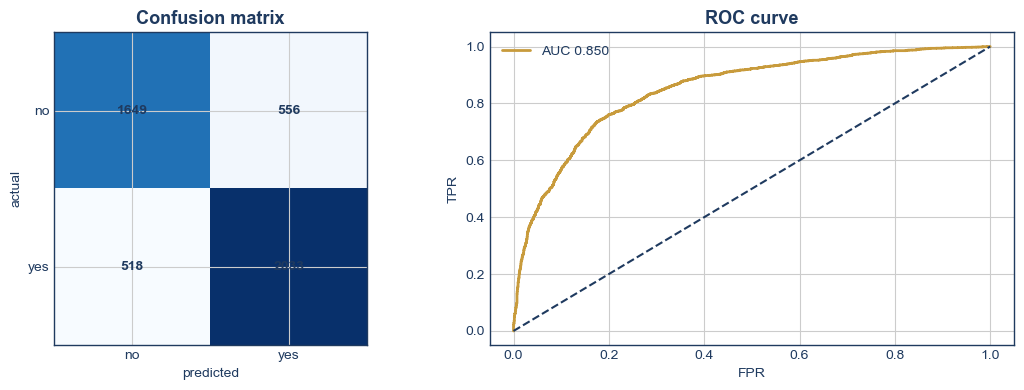

In [6]:
# ---- full evaluation: ROC-AUC, Accuracy, Precision, Recall, F1 ----
pred=(oof>=0.5).astype(int)
print('ROC-AUC  : %.4f'%roc_auc_score(y,oof))
print('Accuracy : %.4f'%accuracy_score(y,pred))
print('Precision: %.4f'%precision_score(y,pred))
print('Recall   : %.4f'%recall_score(y,pred))
print('F1 score : %.4f'%f1_score(y,pred))
print('\n'+classification_report(y,pred,target_names=['No vaccine','Vaccine'],digits=3))
cm=confusion_matrix(y,pred); fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].imshow(cm,cmap=CMAP); ax[0].set_title('Confusion matrix'); ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1])
ax[0].set_xticklabels(['no','yes']); ax[0].set_yticklabels(['no','yes']); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual')
for i in range(2):
    for j in range(2): ax[0].text(j,i,cm[i,j],ha='center',va='center',color=NAVY,fontweight='bold')
fpr,tpr,_=roc_curve(y,oof); ax[1].plot(fpr,tpr,color=GOLD,lw=2,label='AUC %.3f'%roc_auc_score(y,oof)); ax[1].plot([0,1],[0,1],'--',c=NAVY)
ax[1].set_title('ROC curve'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend(); plt.tight_layout(); plt.show()

## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**7. Feature Importance (XAI)**</span>

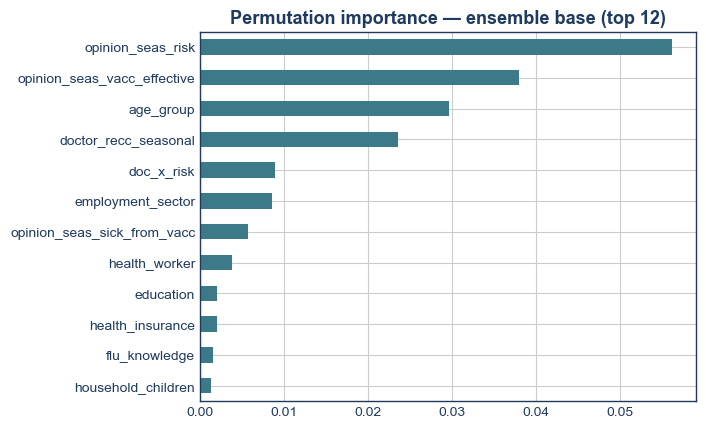

In [7]:
base['LogisticRegression'] if False else None
m=base['GradientBoosting']; m.fit(X,y)
# permutation importance of a representative base model
Xtr,Xva,ytr,yva=train_test_split(X,y,test_size=0.3,stratify=y,random_state=SEED); m.fit(Xtr,ytr)
pi=permutation_importance(m,Xva,yva,scoring='roc_auc',n_repeats=5,random_state=SEED,n_jobs=5)
pd.Series(pi.importances_mean,index=X.columns).sort_values().tail(12).plot(kind='barh',color=TEAL)
plt.title('Permutation importance — ensemble base (top 12)'); plt.show()

## <span style="color:#c89b3c">&#9670;</span> <span style="color:#1f3a5f">**8. Submission**</span>

In [8]:
for m in base.values(): m.fit(X,y)
proba=sum(W[n]*base[n].predict_proba(X_test)[:,1] for n in ns)
pd.DataFrame({ID:test[ID],TARGET:proba}).to_csv('submission_ensemble.csv',index=False)
print('saved submission_ensemble.csv | mean %.3f'%proba.mean())

saved submission_ensemble.csv | mean 0.550
